**3.1 — Install/Import Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
!rm -rf 220141_CNN_Image_Classification
!git clone https://github.com/just-abir/220141_CNN_Image_Classification

Cloning into '220141_CNN_Image_Classification'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 25 (delta 2), reused 25 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 3.15 MiB | 1.73 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

**3.4 — Load Standard FashionMNIST Dataset**

In [ ]:
train_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

**4.1 — Define the CNN Class**

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # After 2 conv+pool layers: 28x28 -> 14x14 -> 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)          # 28x28 -> 14x14

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)          # 14x14 -> 7x7

        x = x.view(x.size(0), -1) # flatten

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
model = CNN(num_classes=10).to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


**STEP 5: Training Loop (Loss Function, Optimizer, Epoch Loop)**

5.1 — Define Loss Function and Optimizer

In [ ]:
# ===== STEP 5.1: Define Loss Function and Optimizer =====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10  # you can increase this later if accuracy is low

In [ ]:
# ===== STEP 5.2: Training Loop =====

# Lists to store history for plotting later
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(num_epochs):

    # ----- Training Phase -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear old gradients
        outputs = model(images)        # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # ----- Validation Phase -----
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    # ----- Print Progress -----
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [1/10] Train Loss: 0.4795, Train Acc: 0.8277 | Val Loss: 0.3422, Val Acc: 0.8741
Epoch [2/10] Train Loss: 0.3037, Train Acc: 0.8901 | Val Loss: 0.2969, Val Acc: 0.8897
Epoch [3/10] Train Loss: 0.2576, Train Acc: 0.9062 | Val Loss: 0.2623, Val Acc: 0.9033
Epoch [4/10] Train Loss: 0.2268, Train Acc: 0.9170 | Val Loss: 0.2458, Val Acc: 0.9118
Epoch [5/10] Train Loss: 0.2025, Train Acc: 0.9256 | Val Loss: 0.2354, Val Acc: 0.9142
Epoch [6/10] Train Loss: 0.1808, Train Acc: 0.9329 | Val Loss: 0.2366, Val Acc: 0.9152
Epoch [7/10] Train Loss: 0.1654, Train Acc: 0.9392 | Val Loss: 0.2306, Val Acc: 0.9161
Epoch [8/10] Train Loss: 0.1471, Train Acc: 0.9444 | Val Loss: 0.2495, Val Acc: 0.9168
Epoch [9/10] Train Loss: 0.1336, Train Acc: 0.9498 | Val Loss: 0.2413, Val Acc: 0.9183
Epoch [10/10] Train Loss: 0.1180, Train Acc: 0.9546 | Val Loss: 0.2553, Val Acc: 0.9221


5.2 — Training Loop with History Trackin

In [ ]:
# ===== STEP 5.2: Training Loop =====

# Lists to store history for plotting later
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(num_epochs):

    # ----- Training Phase -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear old gradients
        outputs = model(images)        # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # ----- Validation Phase -----
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    # ----- Print Progress -----
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [1/10] Train Loss: 0.1004, Train Acc: 0.9624 | Val Loss: 0.2604, Val Acc: 0.9227
Epoch [2/10] Train Loss: 0.0916, Train Acc: 0.9648 | Val Loss: 0.2582, Val Acc: 0.9245
Epoch [3/10] Train Loss: 0.0827, Train Acc: 0.9688 | Val Loss: 0.2765, Val Acc: 0.9191
Epoch [4/10] Train Loss: 0.0753, Train Acc: 0.9712 | Val Loss: 0.2929, Val Acc: 0.9256
Epoch [5/10] Train Loss: 0.0711, Train Acc: 0.9730 | Val Loss: 0.2847, Val Acc: 0.9266
Epoch [6/10] Train Loss: 0.0638, Train Acc: 0.9758 | Val Loss: 0.3482, Val Acc: 0.9235
Epoch [7/10] Train Loss: 0.0580, Train Acc: 0.9780 | Val Loss: 0.3333, Val Acc: 0.9240
Epoch [8/10] Train Loss: 0.0550, Train Acc: 0.9785 | Val Loss: 0.3325, Val Acc: 0.9223
Epoch [9/10] Train Loss: 0.0536, Train Acc: 0.9798 | Val Loss: 0.3447, Val Acc: 0.9206
Epoch [10/10] Train Loss: 0.0481, Train Acc: 0.9820 | Val Loss: 0.3676, Val Acc: 0.9229


5.3 — Save the Trained Model

In [ ]:
# ===== STEP 5.3: Save Model State Dict =====
# Replace 'ID' with your actual student ID
torch.save(model.state_dict(), '220141.pth')
print("Model saved successfully as .pth!")

Model saved successfully as .pth!


STEP 6: Training History Plots (Loss vs Epoch, Accuracy vs Epoch)

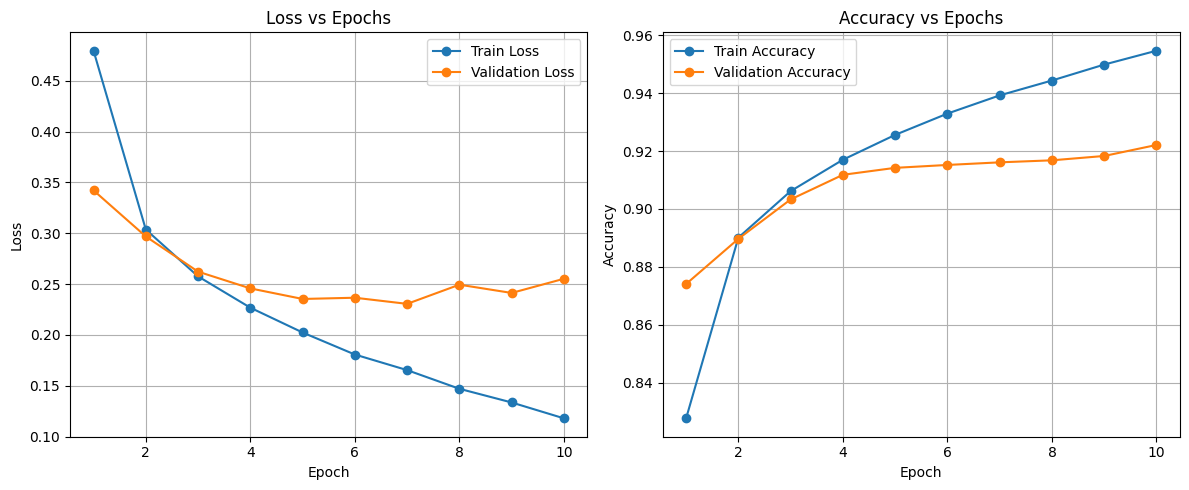

In [ ]:
# ===== STEP 6: Plot Training History =====

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# ----- Plot 1: Loss vs Epochs -----
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history, label='Train Loss', marker='o')
plt.plot(epochs_range, val_loss_history, label='Validation Loss', marker='o')
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# ----- Plot 2: Accuracy vs Epochs -----
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_history, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc_history, label='Validation Accuracy', marker='o')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png')  # save for README later
plt.show()

STEP 7: Confusion Matrix (Heatmap on Standard Test Set)

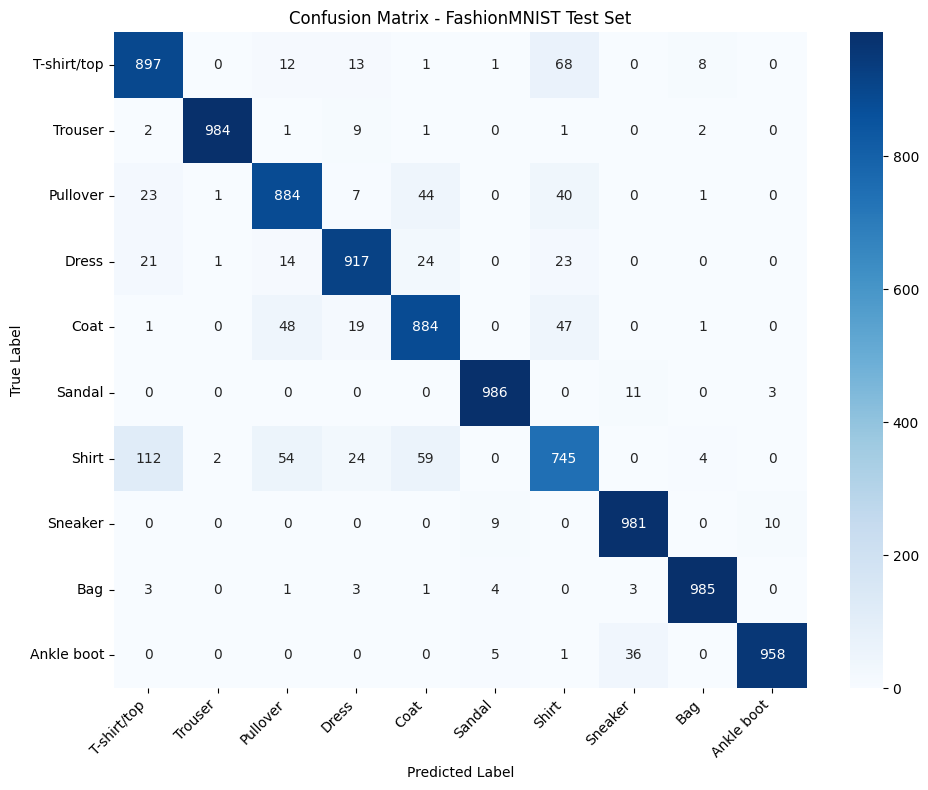

In [ ]:
# ===== STEP 7: Confusion Matrix on Test Set =====

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ----- Compute Confusion Matrix -----
cm = confusion_matrix(all_labels, all_preds)

# ----- Plot as Heatmap -----
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - FashionMNIST Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png')  # save for README later
plt.show()

STEP 8: Load and Process Your 10 Custom Phone Photos

In [ ]:
# ===== STEP 8.1: Check Cloned Dataset Folder =====
import os

dataset_path = '220141_CNN_Image_Classification/dataset'
print(os.listdir(dataset_path))

['09_Women_Dress.jpg', '05_sandal.jpg', '07_Blazer.png', '01_Shoe.jpg', '03_Pant.jpg', '10_Bag.webp', '02_Shirt.jpg', '06_sweater.jpg', '04_Jacket.jpg', '08_Pholo_Shirt.jpg']


In [ ]:
# ===== STEP 8.2: Load & Preprocess a Single Custom Image =====

def load_custom_image(image_path, transform):
    image = Image.open(image_path).convert('RGB')  # open as RGB first
    image = transform(image)                        # apply same pipeline as training data
    image = image.unsqueeze(0)                       # add batch dimension: [1, 1, 28, 28]
    return image

In [ ]:
# ===== STEP 8.3: Load All 10 Custom Images with True Labels =====
custom_images_info = [
    ('01_Shoe.jpg', 'Sneaker'),
    ('02_Shirt.jpg', 'Shirt'),
    ('03_Pant.jpg', 'Trouser'),
    ('04_Jacket.jpg', 'Coat'),
    ('05_sandal.jpg', 'Sandal'),
    ('06_sweater.jpg', 'Pullover'),
    ('07_Blazer.png', 'Coat'),
    ('08_Pholo_Shirt.jpg', 'T-shirt/top'),
    ('09_Women_Dress.jpg', 'Dress'),
    ('10_Bag.webp', 'Bag')
]

custom_tensors = []
custom_true_labels = []
custom_image_paths = []

for filename, true_class in custom_images_info:
    full_path = os.path.join(dataset_path, filename)
    img_tensor = load_custom_image(full_path, transform)
    custom_tensors.append(img_tensor)
    custom_true_labels.append(true_class)
    custom_image_paths.append(full_path)

print(f"Loaded {len(custom_tensors)} custom images successfully.")

Loaded 10 custom images successfully.


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
# ===== STEP 8.4: Corrected Image Loading Function (Auto-Invert) =====

def load_custom_image(image_path, transform):
    image = Image.open(image_path).convert('L')   # convert to grayscale
    image = transform(image)                       # Resize + ToTensor (no normalize yet)

    # Auto-invert: if background is light, flip colors to match FashionMNIST style
    if image.mean() > 0.5:
        image = 1.0 - image

    # Normalize (same as training data: mean=0.5, std=0.5)
    image = (image - 0.5) / 0.5

    image = image.unsqueeze(0)  # add batch dimension
    return image


# Transform WITHOUT normalize (normalization happens manually above, after inversion)
custom_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

In [ ]:
# ===== STEP 8.5: Reload Custom Images with Fixed Preprocessing =====

custom_tensors = []
custom_true_labels = []
custom_image_paths = []

for filename, true_class in custom_images_info:
    full_path = os.path.join(dataset_path, filename)
    img_tensor = load_custom_image(full_path, custom_transform)
    custom_tensors.append(img_tensor)
    custom_true_labels.append(true_class)
    custom_image_paths.append(full_path)

print(f"Loaded {len(custom_tensors)} custom images successfully.")

Loaded 10 custom images successfully.


STEP 9: Run Predictions on Custom Images + Softmax Confidence Scores

In [ ]:
# ===== STEP 9: Predict Custom Images with Confidence Scores =====

model.eval()

custom_predictions = []
custom_confidences = []

with torch.no_grad():
    for img_tensor in custom_tensors:
        img_tensor = img_tensor.to(device)

        output = model(img_tensor)                     # raw logits
        probabilities = torch.softmax(output, dim=1)    # convert to probabilities

        confidence, predicted_idx = torch.max(probabilities, 1)

        predicted_class = class_names[predicted_idx.item()]
        confidence_pct = confidence.item() * 100

        custom_predictions.append(predicted_class)
        custom_confidences.append(confidence_pct)

# ----- Print Results -----
for i in range(len(custom_predictions)):
    print(f"Image: {os.path.basename(custom_image_paths[i])} | "
          f"True: {custom_true_labels[i]} | "
          f"Pred: {custom_predictions[i]} ({custom_confidences[i]:.1f}%)")

Image: 01_Shoe.jpg | True: Sneaker | Pred: Bag (61.8%)
Image: 02_Shirt.jpg | True: Shirt | Pred: Shirt (58.8%)
Image: 03_Pant.jpg | True: Trouser | Pred: Trouser (99.7%)
Image: 04_Jacket.jpg | True: Coat | Pred: Coat (96.9%)
Image: 05_sandal.jpg | True: Sandal | Pred: Bag (99.1%)
Image: 06_sweater.jpg | True: Pullover | Pred: Shirt (69.1%)
Image: 07_Blazer.png | True: Coat | Pred: T-shirt/top (41.9%)
Image: 08_Pholo_Shirt.jpg | True: T-shirt/top | Pred: T-shirt/top (99.5%)
Image: 09_Women_Dress.jpg | True: Dress | Pred: Bag (75.5%)
Image: 10_Bag.webp | True: Bag | Pred: Bag (93.0%)


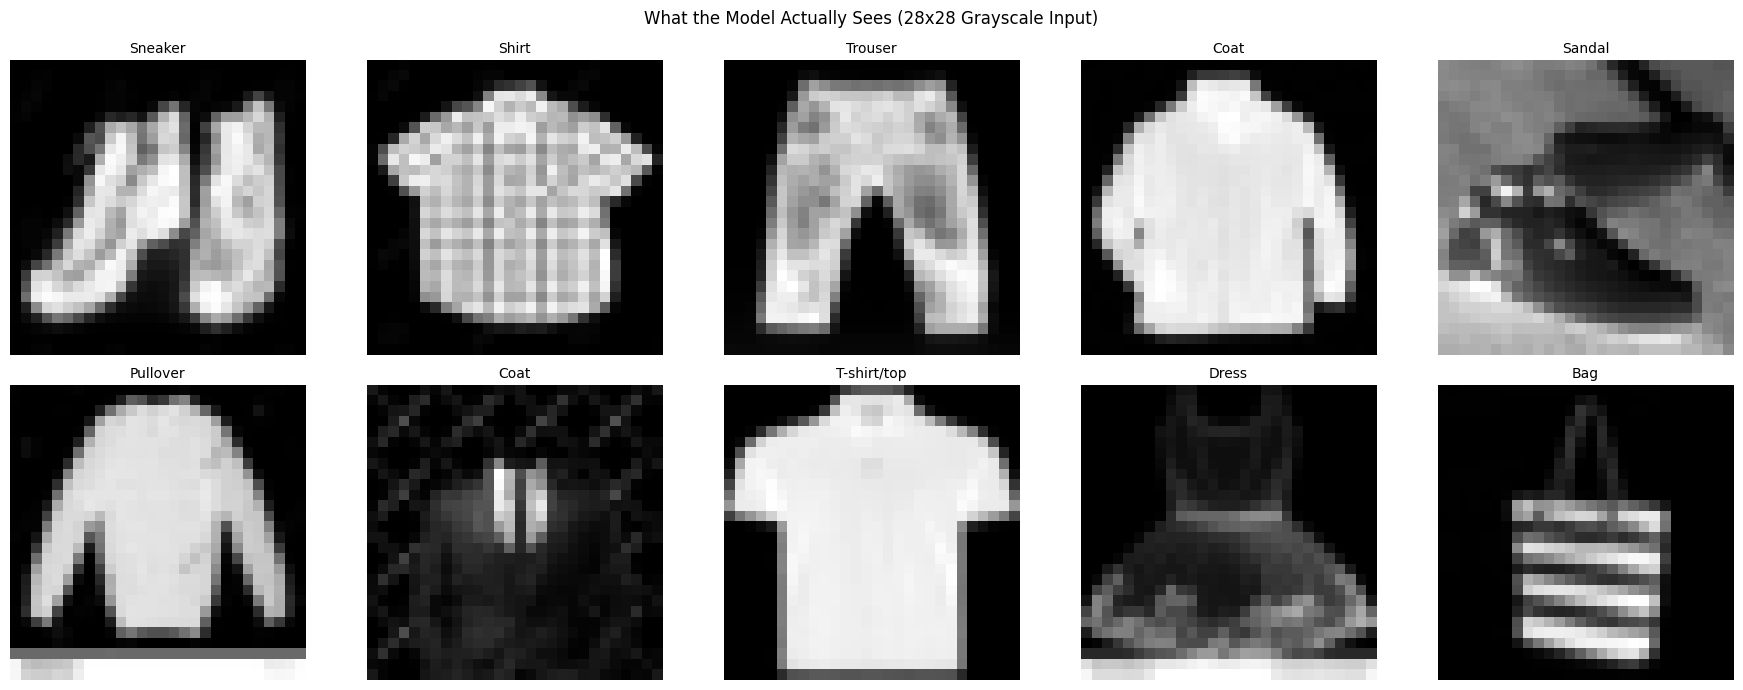

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i in range(len(custom_tensors)):
    img = custom_tensors[i].squeeze()
    img = img * 0.5 + 0.5

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(custom_true_labels[i], fontsize=10)

plt.suptitle("What the Model Actually Sees (28x28 Grayscale Input)")
plt.tight_layout()
plt.show()

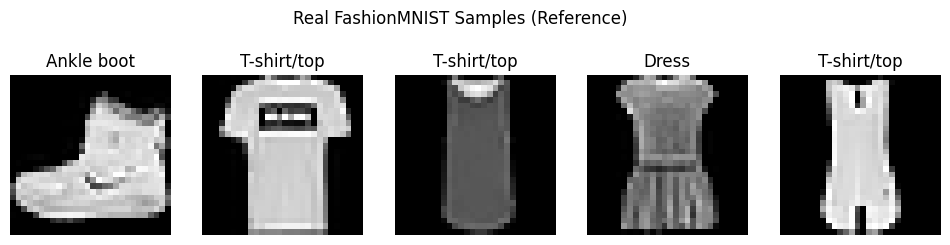

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img, label = train_dataset[i]
    img = img.squeeze() * 0.5 + 0.5
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(class_names[label])
plt.suptitle("Real FashionMNIST Samples (Reference)")
plt.show()

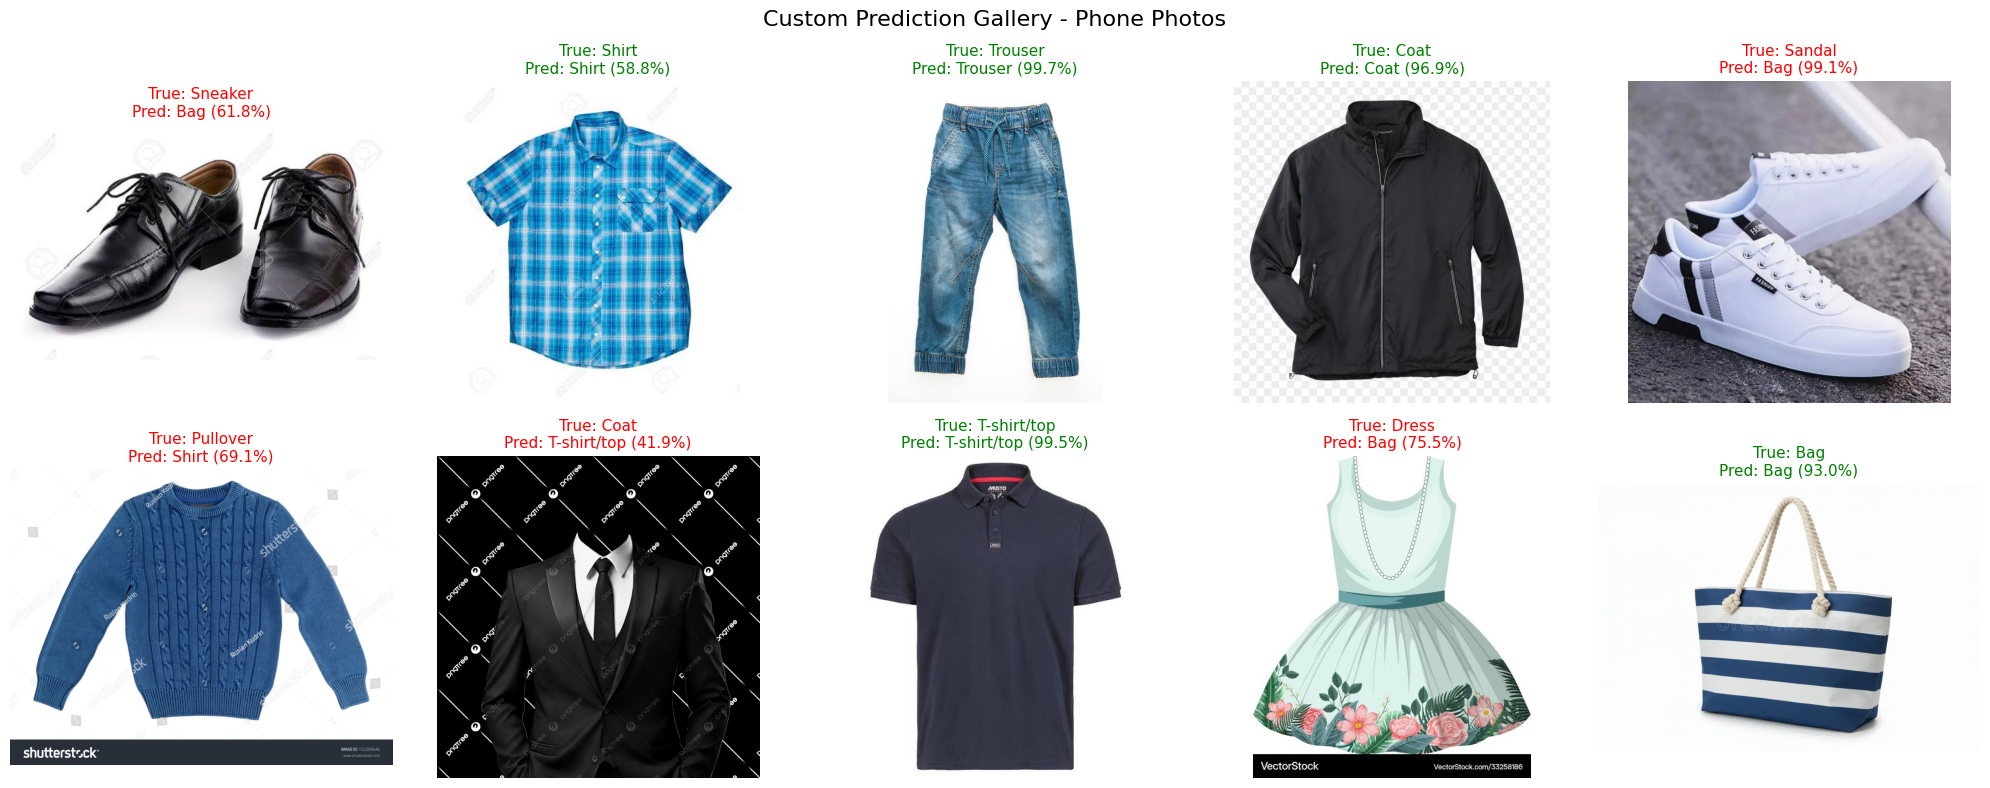

In [ ]:
# ===== STEP 10: Custom Prediction Gallery =====

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i in range(len(custom_image_paths)):
    # Load original image (not the tensor) just for display purposes
    original_img = Image.open(custom_image_paths[i]).convert('RGB')

    axes[i].imshow(original_img)
    axes[i].axis('off')

    # Color the title green if correct, red if wrong
    color = 'green' if custom_predictions[i] == custom_true_labels[i] else 'red'

    axes[i].set_title(
        f"True: {custom_true_labels[i]}\nPred: {custom_predictions[i]} ({custom_confidences[i]:.1f}%)",
        color=color,
        fontsize=11
    )

plt.suptitle("Custom Prediction Gallery - Phone Photos", fontsize=16)
plt.tight_layout()
plt.savefig('custom_prediction_gallery.png')  # save for README later
plt.show()

STEP 11: Visual Error Analysis (3 Random Misclassified Images from Standard Test Set)

Total misclassified samples collected: 52


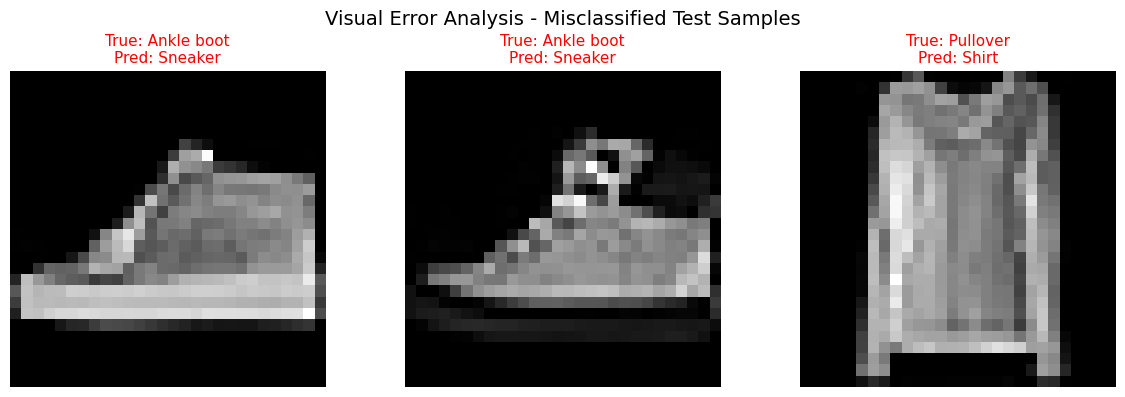

In [ ]:
# ===== STEP 11: Visual Error Analysis =====

model.eval()

misclassified_images = []
misclassified_true = []
misclassified_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Find indices where prediction != true label
        wrong_mask = (predicted != labels)

        if wrong_mask.sum() > 0:
            wrong_images = images[wrong_mask]
            wrong_true = labels[wrong_mask]
            wrong_pred = predicted[wrong_mask]

            for i in range(wrong_images.size(0)):
                misclassified_images.append(wrong_images[i].cpu())
                misclassified_true.append(wrong_true[i].cpu().item())
                misclassified_pred.append(wrong_pred[i].cpu().item())

        # Stop early once we have enough samples (optional speed-up)
        if len(misclassified_images) >= 50:
            break

print(f"Total misclassified samples collected: {len(misclassified_images)}")

# ----- Randomly select 3 misclassified images -----
import random

random_indices = random.sample(range(len(misclassified_images)), 3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, idx in enumerate(random_indices):
    img = misclassified_images[idx].squeeze()  # remove channel dim for display

    # Unnormalize for display (since we normalized with mean=0.5, std=0.5)
    img = img * 0.5 + 0.5

    true_label = class_names[misclassified_true[idx]]
    pred_label = class_names[misclassified_pred[idx]]

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color='red', fontsize=11)

plt.suptitle("Visual Error Analysis - Misclassified Test Samples", fontsize=14)
plt.tight_layout()
plt.savefig('error_analysis.png')  # save for README later
plt.show()